# 🚗 NYC Uber Rides Data Analysis

## 0 · Importing Libraries

In [10]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'font.family': 'DejaVu Sans'})
UBER_BLACK = '#000000'
UBER_GREEN = '#06C167'
ACCENT     = '#276EF1'

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 1 · Data Loading & Overview

In [11]:
df_raw= pd.read_csv('uber-raw-data-apr14.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (564516, 4)


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [12]:
# Basic info
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


In [13]:
df_raw.describe()

,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


## 2. Data Cleaning

In [23]:
df = df_raw.copy()

# Rename Cloumns
df.columns = ['date_time', 'lat', 'lon', 'base']

In [24]:
# Parse Datetime
df['date_time'] = pd.to_datetime(df['date_time'], format='%m/%d/%Y %H:%M:%S')
df['date_time'].dtype

dtype('<M8[ns]')

In [25]:
# Drop duplicates and null values
before = len(df)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print(f'Removed {before - len(df):,} duplicate / null rows')

Removed 7,749 duplicate / null rows


In [26]:
# Geo sanity filter (NYC bounding box)
df = df[(df['lat'].between(40.4, 41.0)) & (df['lon'].between(-74.3, -73.6))]
print(f'Remaining after geo-filter: {len(df):,} rows')

Remaining after geo-filter: 555,423 rows


In [27]:
df.head(3)

,date_time,lat,lon,base
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512


## 3. Feature Engineering

In [28]:
df['year']        = df['date_time'].dt.year
df['month']       = df['date_time'].dt.month
df['day']         = df['date_time'].dt.day
df['hour']        = df['date_time'].dt.hour
df['minute']      = df['date_time'].dt.minute
df['day_of_week'] = df['date_time'].dt.dayofweek   # 0=Mon … 6=Sun
df['day_name']    = df['date_time'].dt.day_name()
df['week']        = df['date_time'].dt.isocalendar().week.astype(int)

In [29]:
# Is it a weekend?
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

In [30]:
# Rush-hour flag (7-10 AM or 5-7 PM on weekdays)
df['is_rush_hour'] = (
    (~df['is_weekend'].astype(bool)) &
    (df['hour'].isin(list(range(7,11)) + list(range(17,20))))
).astype(int)

In [31]:
# Time-of-day buckets
bins   = [-1, 5, 11, 17, 20, 24]
labels = ['Night (0-5)', 'Morning (6-11)', 'Afternoon (12-17)', 'Evening (18-20)', 'Late Night (21-23)']
df['time_of_day'] = pd.cut(df['hour'], bins=bins, labels=labels)

In [33]:
print('Feature columns added:')
print(df.columns.tolist())
df.head(7)

Feature columns added:
['date_time', 'lat', 'lon', 'base', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week', 'day_name', 'week', 'is_weekend', 'is_rush_hour', 'time_of_day']


,date_time,lat,lon,base,year,month,day,hour,minute,day_of_week,day_name,week,is_weekend,is_rush_hour,time_of_day
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,2014,4,1,0,11,1,Tuesday,14,0,0,Night (0-5)
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,2014,4,1,0,17,1,Tuesday,14,0,0,Night (0-5)
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,2014,4,1,0,21,1,Tuesday,14,0,0,Night (0-5)
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,2014,4,1,0,28,1,Tuesday,14,0,0,Night (0-5)
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,2014,4,1,0,33,1,Tuesday,14,0,0,Night (0-5)
5,2014-04-01 00:33:00,40.7383,-74.0403,B02512,2014,4,1,0,33,1,Tuesday,14,0,0,Night (0-5)
6,2014-04-01 00:39:00,40.7223,-73.9887,B02512,2014,4,1,0,39,1,Tuesday,14,0,0,Night (0-5)


## 4 · Exploratory Data Analysis (EDA)

### 4.1 Rides Per Hour of Day

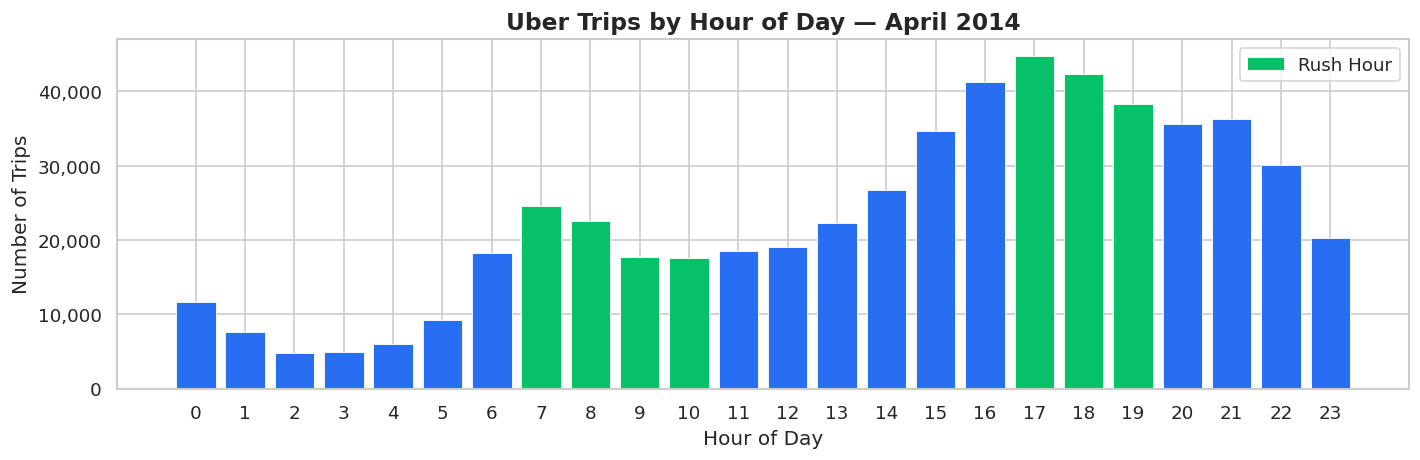

Peak hour: 17 h with 44,803 trips


In [35]:
hourly = df.groupby('hour').size().reset_index(name='trips')

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(hourly['hour'], hourly['trips'], color=ACCENT, edgecolor='white', linewidth=0.5)
ax.bar(hourly.loc[hourly['hour'].isin([7,8,9,10,17,18,19]), 'hour'],
       hourly.loc[hourly['hour'].isin([7,8,9,10,17,18,19]), 'trips'],
       color=UBER_GREEN, edgecolor='white', linewidth=0.5, label='Rush Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Trips')
ax.set_title('Uber Trips by Hour of Day — April 2014', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()
print('Peak hour:', hourly.loc[hourly['trips'].idxmax(), 'hour'], 'h with',
      f"{hourly['trips'].max():,}", 'trips')

### 4.2 Rides by Day of Week

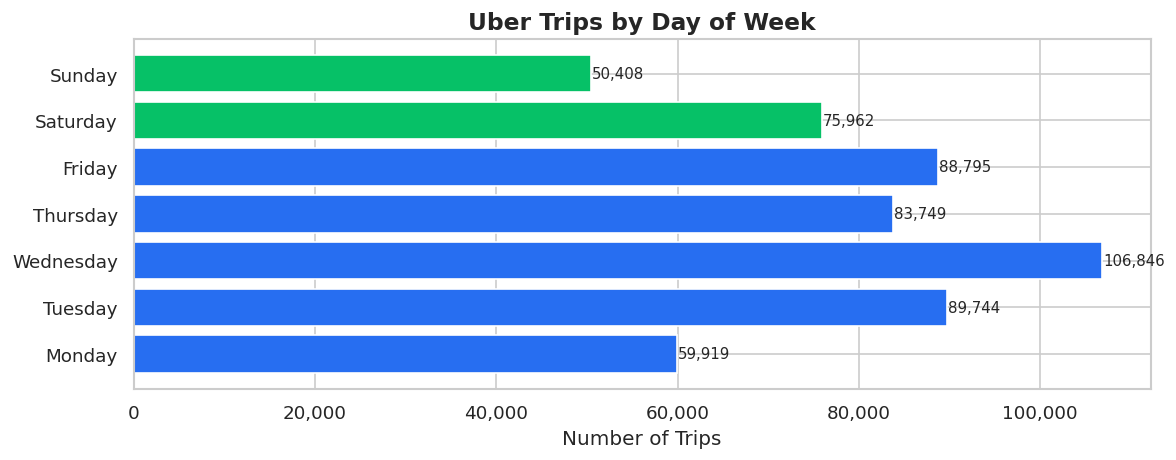

In [55]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_name').size().reindex(day_order).reset_index(name='trips')

fig, ax = plt.subplots(figsize=(10, 4))
colors = [UBER_GREEN if d in ['Saturday','Sunday'] else ACCENT for d in day_order]
ax.barh(daily['day_name'], daily['trips'], color=colors)
ax.set_xlabel('Number of Trips')
ax.set_title('Uber Trips by Day of Week', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(daily['trips']):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 4.3 Trips Ovet the Month (Daily Trends)

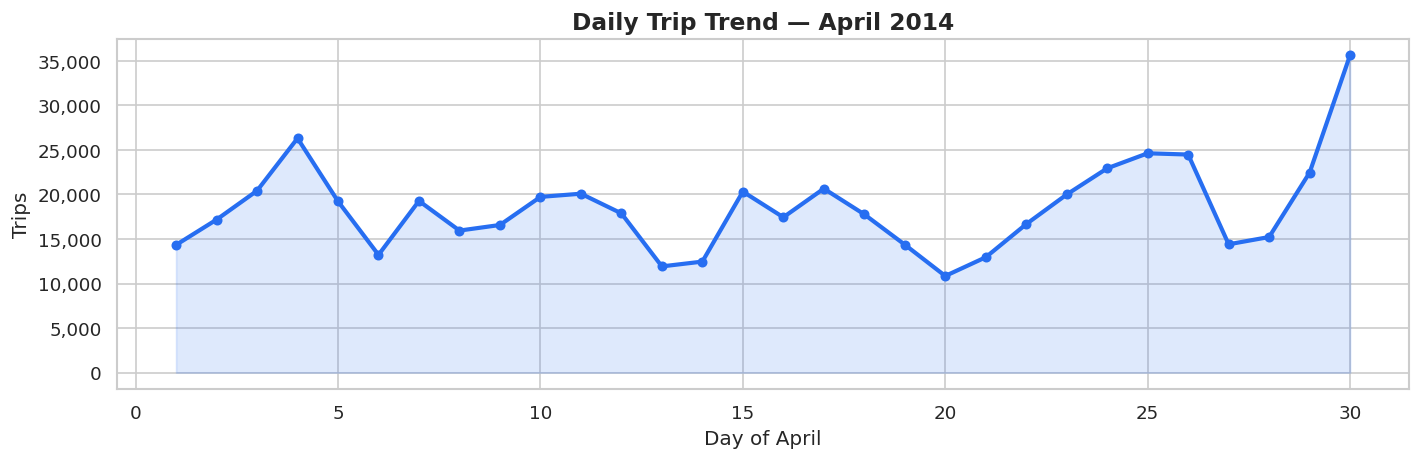

In [37]:
day_trend = df.groupby('day').size().reset_index(name='trips')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(day_trend['day'], day_trend['trips'], color=ACCENT, lw=2.5, marker='o', markersize=5)
ax.fill_between(day_trend['day'], day_trend['trips'], alpha=0.15, color=ACCENT)
ax.set_xlabel('Day of April')
ax.set_ylabel('Trips')
ax.set_title('Daily Trip Trend — April 2014', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 4.4 Heatmap — Hour vs Day of Week

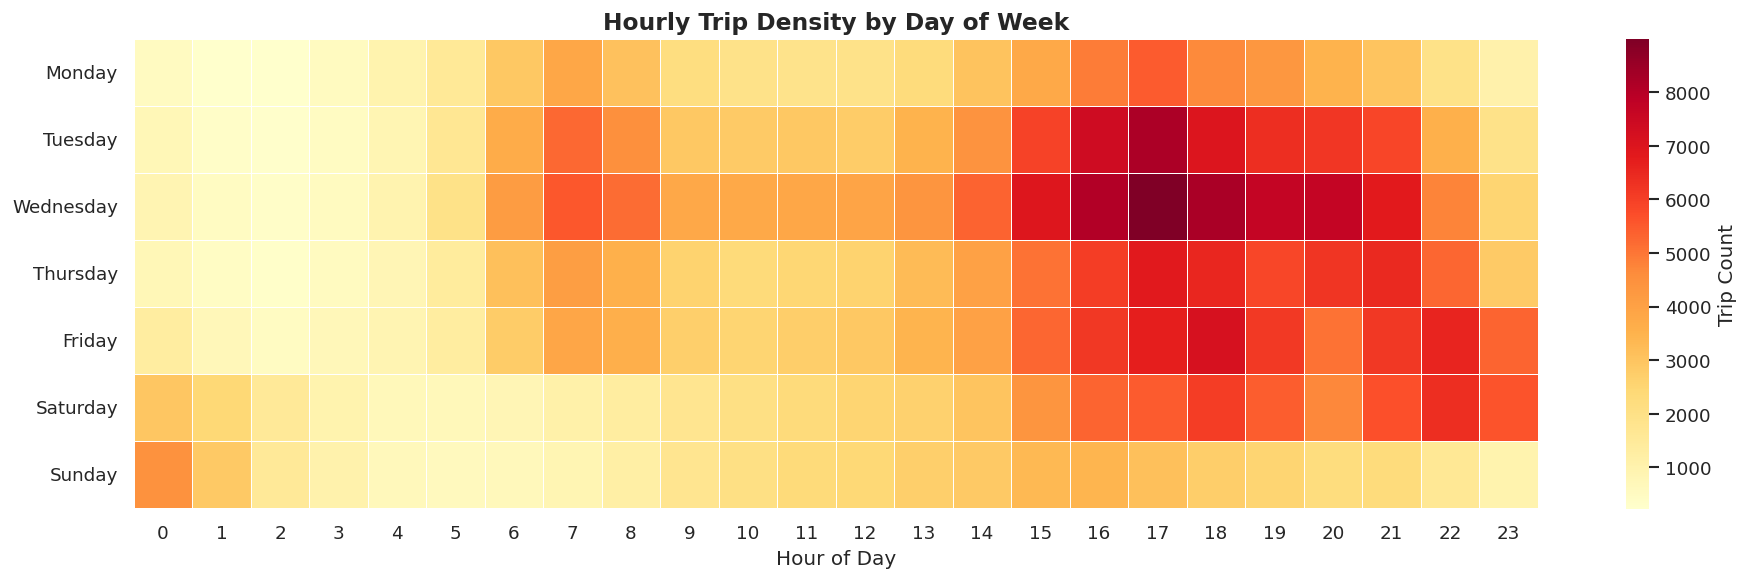

In [38]:
heat = df.groupby(['day_name', 'hour']).size().unstack(fill_value=0)
heat = heat.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heat, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Trip Count'})
ax.set_title('Hourly Trip Density by Day of Week', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.5 Trips by Base (Dispatch Center)

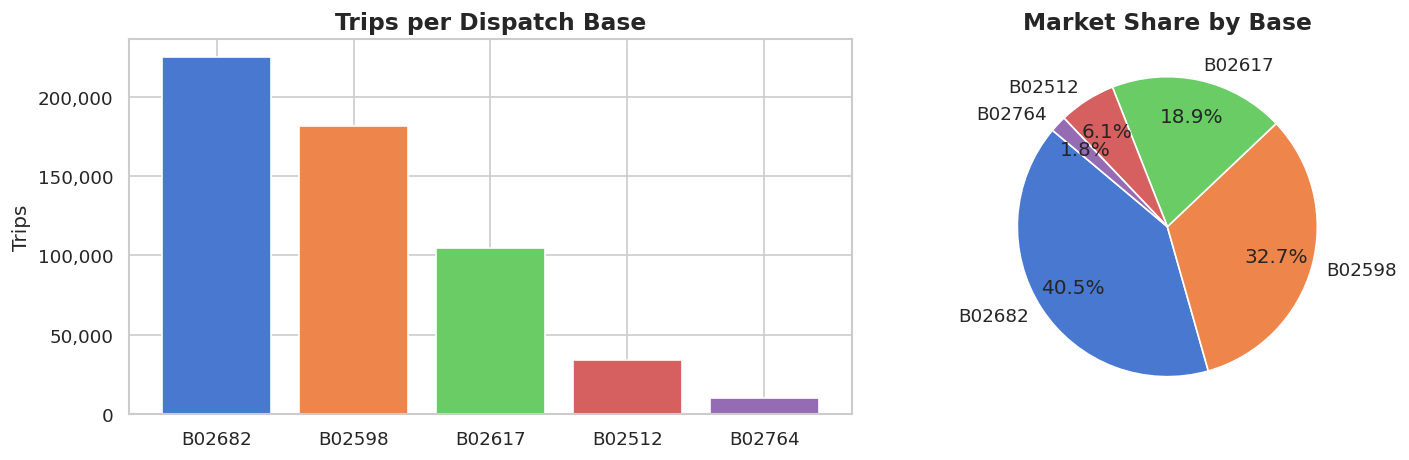

In [39]:
base_counts = df['base'].value_counts().reset_index()
base_counts.columns = ['base', 'trips']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar
axes[0].bar(base_counts['base'], base_counts['trips'],
            color=sns.color_palette('muted', len(base_counts)))
axes[0].set_title('Trips per Dispatch Base', fontweight='bold')
axes[0].set_ylabel('Trips')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie
axes[1].pie(base_counts['trips'], labels=base_counts['base'],
            autopct='%1.1f%%', colors=sns.color_palette('muted', len(base_counts)),
            startangle=140, pctdistance=0.75)
axes[1].set_title('Market Share by Base', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 Geographic Pickup Distribution

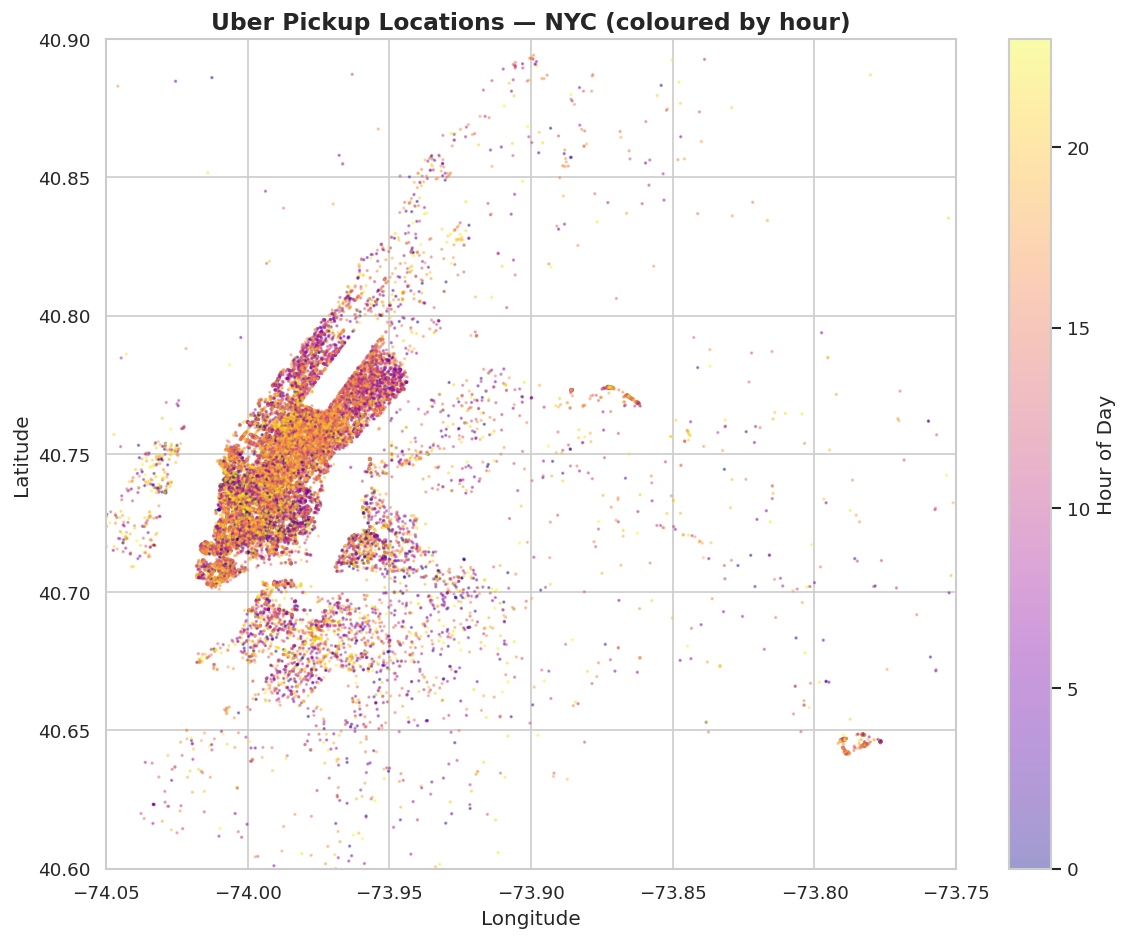

In [40]:
sample = df.sample(n=min(30_000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(sample['lon'], sample['lat'],
                c=sample['hour'], cmap='plasma',
                s=1, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Hour of Day')
ax.set_title('Uber Pickup Locations — NYC (coloured by hour)', fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-74.05, -73.75)
ax.set_ylim(40.60, 40.90)
plt.tight_layout()
plt.show()

### 4.7 Rush Hour vs Non-Rush Hour

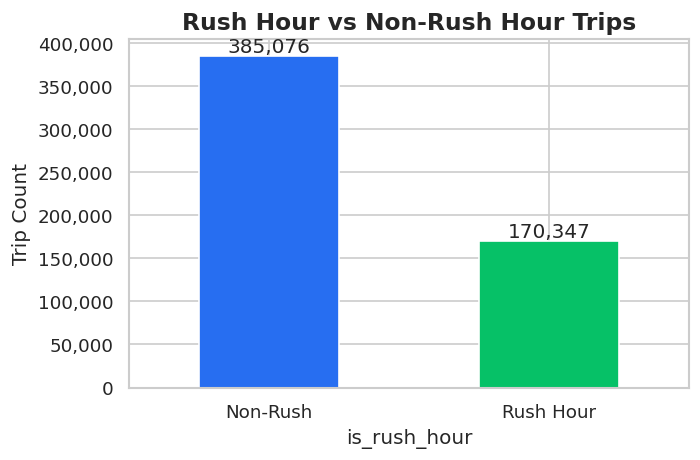

In [41]:
rush_counts = df['is_rush_hour'].value_counts().rename({0: 'Non-Rush', 1: 'Rush Hour'})

fig, ax = plt.subplots(figsize=(6, 4))
rush_counts.plot(kind='bar', color=[ACCENT, UBER_GREEN], ax=ax, rot=0)
ax.set_title('Rush Hour vs Non-Rush Hour Trips', fontweight='bold')
ax.set_ylabel('Trip Count')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

### 4.8 Time-of-Day Distribution

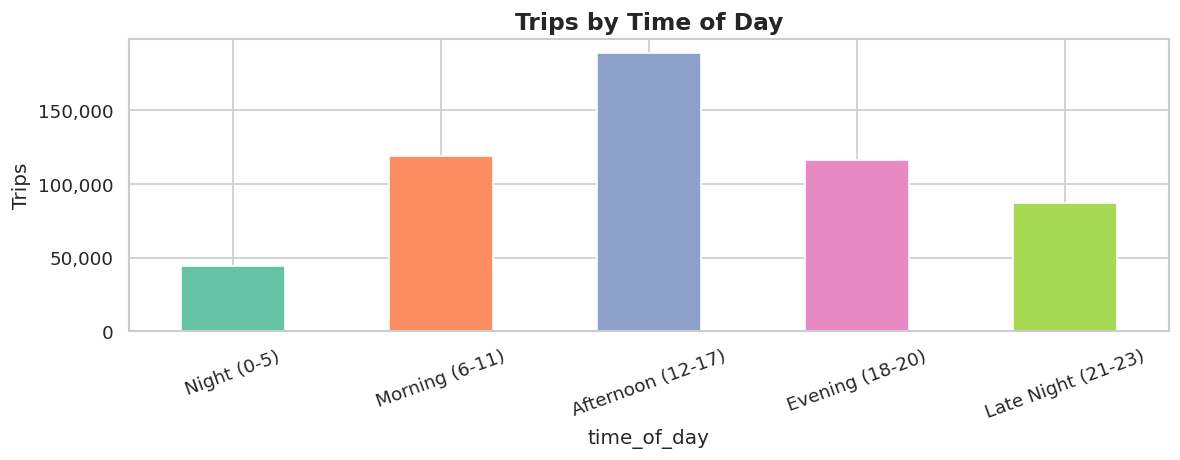

In [42]:
tod = df['time_of_day'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(10, 4))
tod.plot(kind='bar', color=sns.color_palette('Set2', len(tod)), ax=ax, rot=20)
ax.set_title('Trips by Time of Day', fontweight='bold')
ax.set_ylabel('Trips')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 5 · Demand Aggregation for Modelling

In [43]:
# Aggregate to hourly demand (trips per hour)
demand = (
    df.groupby(['day', 'day_of_week', 'hour', 'is_weekend', 'is_rush_hour'])
    .size()
    .reset_index(name='trip_count')
)

# Lag features (previous hour, same hour previous day)
demand = demand.sort_values(['day', 'hour']).reset_index(drop=True)
demand['lag_1h']  = demand['trip_count'].shift(1)
demand['lag_24h'] = demand['trip_count'].shift(24)
demand['rolling_3h_mean'] = demand['trip_count'].shift(1).rolling(3).mean()

demand.dropna(inplace=True)
print(f'Modelling dataset: {demand.shape}')
demand.head()

Modelling dataset: (696, 9)


,day,day_of_week,hour,is_weekend,is_rush_hour,trip_count,lag_1h,lag_24h,rolling_3h_mean
24,2,2,0,0,0,161,312.0,133.0,566.000000
25,2,2,1,0,0,81,161.0,62.0,331.666667
26,2,2,2,0,0,58,81.0,50.0,184.666667
27,2,2,3,0,0,76,58.0,90.0,100.000000
28,2,2,4,0,0,193,76.0,161.0,71.666667


## 6 · Predictive Analysis — Demand Forecasting

In [45]:
FEATURES = ['day_of_week', 'hour', 'is_weekend', 'is_rush_hour',
            'lag_1h', 'lag_24h', 'rolling_3h_mean']
TARGET   = 'trip_count'

X = demand[FEATURES]
y = demand[TARGET]

# Chronological train/test split (80/20)
split = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 556 | Test: 140


In [49]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = mean_squared_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    print(f'{name:<35}  MAE={mae:7.1f}  RMSE={rmse:7.1f}  R²={r2:.4f}')
    return pred, model

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting (GBT)': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                          max_depth=4, random_state=42),
}

results = {}
print(f'{"Model":<35}  {"MAE":>10}  {"RMSE":>10}  {"R²":>8}')
print('-'*65)
for name, m in models.items():
    X_tr = X_train_sc if 'Regression' in name else X_train
    X_te = X_test_sc  if 'Regression' in name else X_test
    pred, fitted = evaluate(name, m, X_tr, y_train, X_te, y_test)
    results[name] = {'pred': pred, 'model': fitted}

Model                                       MAE        RMSE        R²
-----------------------------------------------------------------
Linear Regression                    MAE=  139.0  RMSE=36019.0  R²=0.9203
Ridge Regression                     MAE=  140.0  RMSE=36328.2  R²=0.9197
Random Forest                        MAE=  131.1  RMSE=42591.8  R²=0.9058
Gradient Boosting (GBT)              MAE=  113.7  RMSE=31608.1  R²=0.9301


### 6.1 Actual vs Predicted — Best Model (GBT)

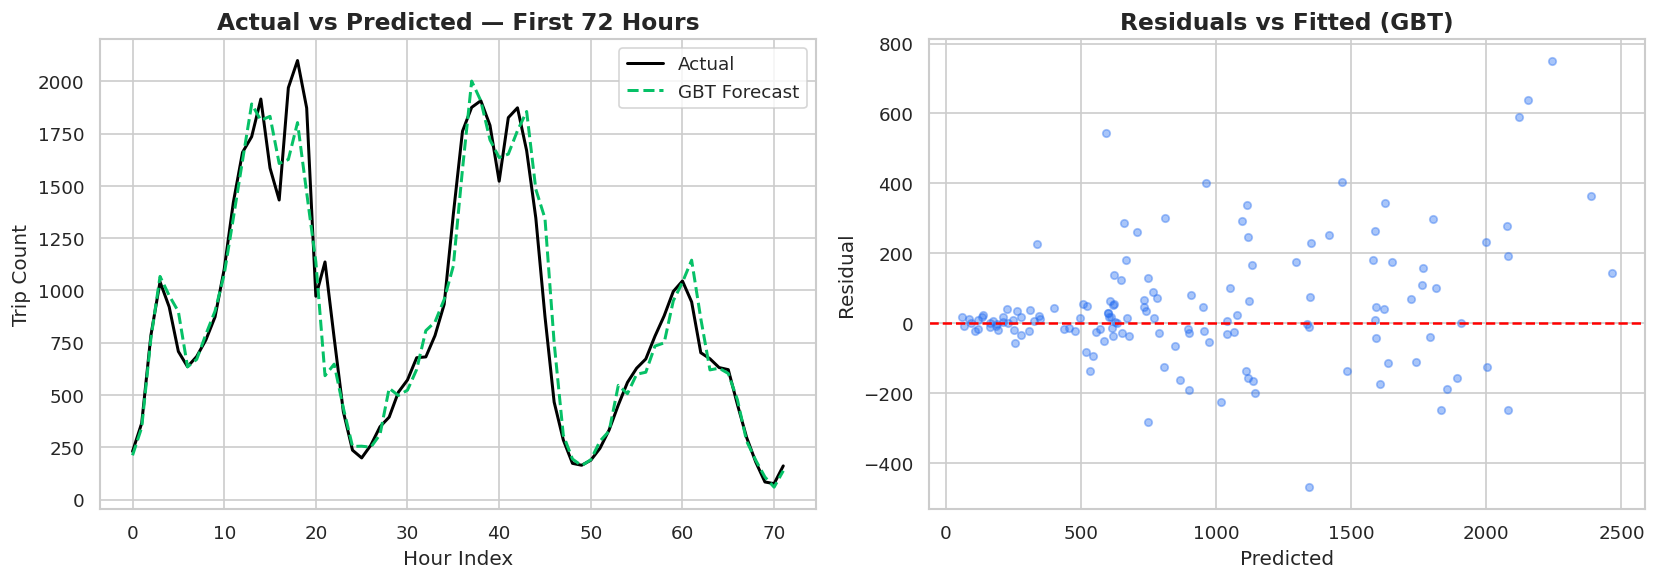

In [50]:
best_pred = results['Gradient Boosting (GBT)']['pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time-series plot
axes[0].plot(y_test.values[:72], label='Actual', color=UBER_BLACK, lw=1.8)
axes[0].plot(best_pred[:72],     label='GBT Forecast', color=UBER_GREEN, lw=1.8, ls='--')
axes[0].set_title('Actual vs Predicted — First 72 Hours', fontweight='bold')
axes[0].set_xlabel('Hour Index')
axes[0].set_ylabel('Trip Count')
axes[0].legend()

# Residual scatter
residuals = y_test.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.4, color=ACCENT, s=20)
axes[1].axhline(0, color='red', lw=1.5, ls='--')
axes[1].set_title('Residuals vs Fitted (GBT)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

### 6.2 Feature Importance — Gradient Boosting

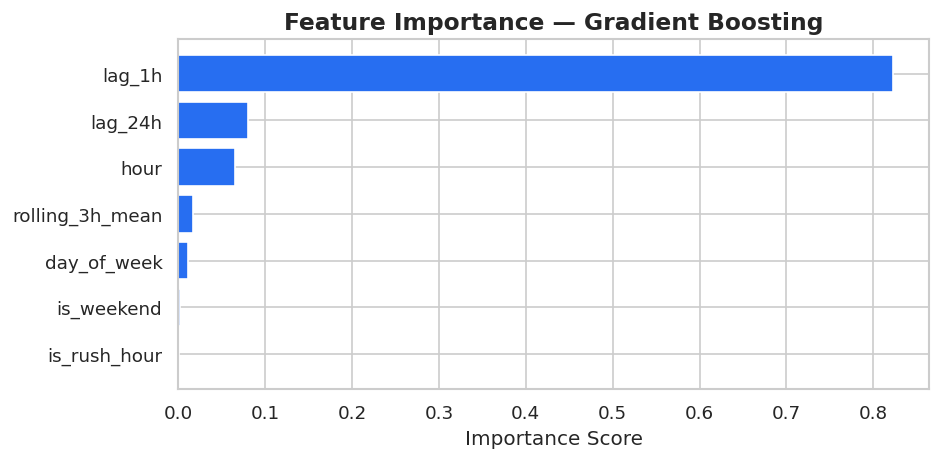

In [51]:
gbt_model = results['Gradient Boosting (GBT)']['model']
importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': gbt_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance_df['feature'], importance_df['importance'],
        color=ACCENT)
ax.set_title('Feature Importance — Gradient Boosting', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 6.3 Model Comparison Bar Chart

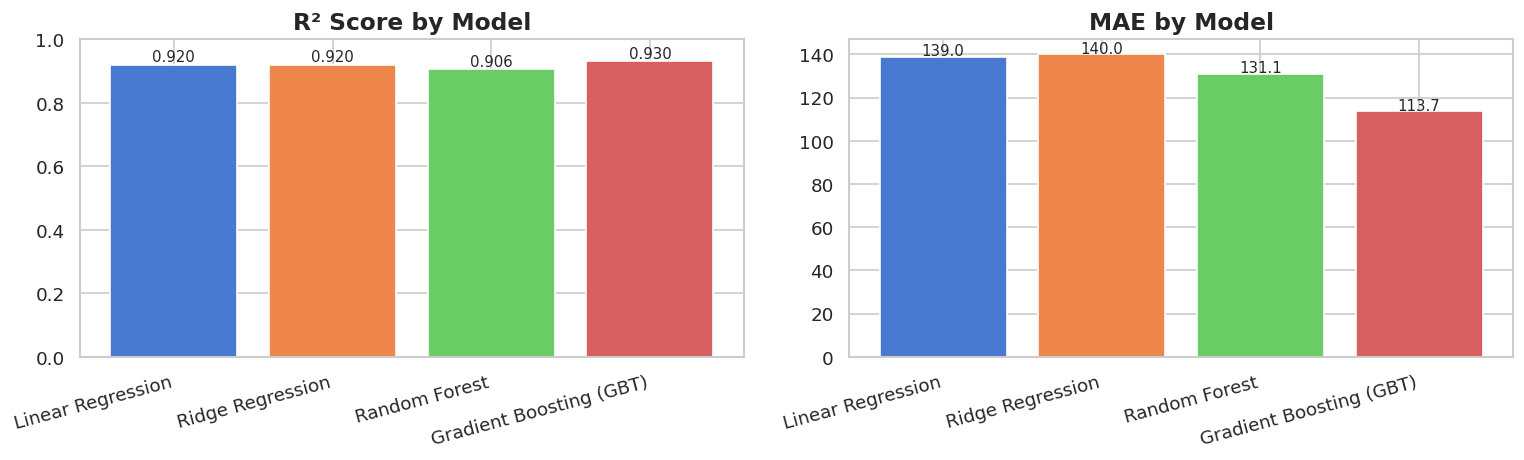

In [52]:
model_names = list(models.keys())
r2_scores   = [r2_score(y_test, results[m]['pred']) for m in model_names]
mae_scores  = [mean_absolute_error(y_test, results[m]['pred']) for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pal = sns.color_palette('muted', len(model_names))

axes[0].bar(model_names, r2_scores, color=pal)
axes[0].set_title('R² Score by Model', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(model_names, mae_scores, color=pal)
axes[1].set_title('MAE by Model', fontweight='bold')
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7 · Key Insights Summary

In [53]:
peak_hour = hourly.loc[hourly['trips'].idxmax(), 'hour']
peak_day  = daily.loc[daily['trips'].idxmax(), 'day_name']
top_base  = base_counts.iloc[0, 0]
top_base_pct = 100 * base_counts.iloc[0, 1] / base_counts['trips'].sum()
gbt_r2    = r2_score(y_test, results['Gradient Boosting (GBT)']['pred'])
gbt_mae   = mean_absolute_error(y_test, results['Gradient Boosting (GBT)']['pred'])

print('=' * 60)
print('            UBER DATA ANALYSIS — KEY FINDINGS')
print('=' * 60)
print(f'  Total Trips Analysed   : {len(df):,}')
print(f'  Peak Hour              : {peak_hour}:00')
print(f'  Busiest Day            : {peak_day}')
print(f'  Top Dispatch Base      : {top_base} ({top_base_pct:.1f}% share)')
print(f'  Rush-Hour Trip Share   : {100*df["is_rush_hour"].mean():.1f}%')
print(f'  Weekend Trip Share     : {100*df["is_weekend"].mean():.1f}%')
print()
print('  ── Predictive Model (GBT) ──')
print(f'  R² Score               : {gbt_r2:.4f}')
print(f'  MAE (trips/hour)       : {gbt_mae:.1f}')
print(f'  Champion Feature       : lag_1h (prior hour demand)')
print('=' * 60)

            UBER DATA ANALYSIS — KEY FINDINGS
  Total Trips Analysed   : 555,423
  Peak Hour              : 17:00
  Busiest Day            : Wednesday
  Top Dispatch Base      : B02682 (40.5% share)
  Rush-Hour Trip Share   : 30.7%
  Weekend Trip Share     : 22.8%

  ── Predictive Model (GBT) ──
  R² Score               : 0.9301
  MAE (trips/hour)       : 113.7
  Champion Feature       : lag_1h (prior hour demand)
